In [2]:
from typing import Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage, BaseMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated

In [3]:
load_dotenv()

True

In [4]:
llm = ChatOpenAI(model='gpt-4.1-mini')

In [5]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [16]:
def chat_node(state: ChatState):
    decision = interrupt({
        'type': 'approval', 
        'reason': 'Model is about to answer a user question.', 
        'question': state['messages'][-1].content, 
        'instruction': 'Approve this question? yes/no'
    })

    if decision['approved'] == 'no': 
        return {'messages': [AIMessage(content="Not approved.")]}
    else: 
        response = llm.invoke(state['messages'])
        return {'messages': [response]}

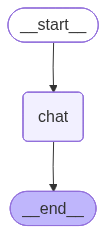

In [17]:
builder = StateGraph(ChatState)
builder.add_node('chat', chat_node)
builder.add_edge(START, 'chat')
builder.add_edge('chat', END)

checkpointer = MemorySaver()

app = builder.compile(checkpointer=checkpointer)
app

In [30]:
config = {'configurable': {'thread_id': '1234'}}
initial_input = {
    'messages': [
        ('user', 'Explain gradient descent in very simple terms.')
        ]
}
result = app.invoke(initial_input, config)

In [31]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='a8a72e4a-9f1c-43f4-9db6-fd0ecc3e49ee'),
  AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='083ea27b-7c72-4977-8e6b-2529eefab5b4', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='f7d4a42e-8c95-4dfc-85bf-c329eaffc180'),
  AIMessage(content='Sure! Imagine you\'re on a hill covered in thick fog, and you want to find the lowest point of the valley. Because you can\'t see very far, you look around your feet to see which direction goes downhill the most. Then, you take a small step in that direction. Repeating this—looking around and stepping downhill again and again—you slowly make your way down to the bottom.\n\nIn simple terms, **gradient descent** is a method used in math and computer science to find the minimum va

In [32]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [33]:
user_input = input(f'\nBackend message - {message} ]n Approtve this question (y/n)')

In [34]:
final_result = app.invoke(
    Command(resume={'approved': user_input}), 
    config=config,
)

In [35]:
print(final_result)

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='a8a72e4a-9f1c-43f4-9db6-fd0ecc3e49ee'), AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='083ea27b-7c72-4977-8e6b-2529eefab5b4', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='f7d4a42e-8c95-4dfc-85bf-c329eaffc180'), AIMessage(content='Sure! Imagine you\'re on a hill covered in thick fog, and you want to find the lowest point of the valley. Because you can\'t see very far, you look around your feet to see which direction goes downhill the most. Then, you take a small step in that direction. Repeating this—looking around and stepping downhill again and again—you slowly make your way down to the bottom.\n\nIn simple terms, **gradient descent** is a method used in math and computer science to find the minimum value of